# 🎓 Módulo de Deep Learning
## Programa de Especialización en Inteligencia Artificial aplicada a los negocios

---

### 📋 Información del Proyecto

| Campo | Información |
|-------|-------------|
| **Nombre del Estudiante** | Christian Max Alcocer Evangelista |
| **Título del Proyecto** | Uso de Deep Learning para mejorar el mantenimiento Industrial en una planta |
| **Fecha de Entrega** | 29/04/2026 |
| **Profesor** | Carlos Marino |

---

## 📑 Índice

1. [Resumen Ejecutivo](#1-resumen-ejecutivo)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Definición del Problema de Negocio](#3-definición-del-problema-de-negocio)
4. [Carga y Exploración de Datos](#4-carga-y-exploración-de-datos)
5. [Preprocesamiento de Datos](#5-preprocesamiento-de-datos)
6. [Diseño y Arquitectura del Modelo](#6-diseño-y-arquitectura-del-modelo)
7. [Entrenamiento del Modelo](#7-entrenamiento-del-modelo)
8. [Evaluación y Métricas](#8-evaluación-y-métricas)
9. [Interpretación de Resultados](#9-interpretación-de-resultados)
10. [Conclusiones y Recomendaciones de Negocio](#10-conclusiones-y-recomendaciones-de-negocio)
11. [Referencias](#11-referencias)

---
## 1. Resumen Ejecutivo

**Instrucciones:** Proporcione un resumen conciso (máximo 300 palabras) que incluya:
- Problema de negocio abordado
- Metodología utilizada
- Principales hallazgos
- Impacto esperado en el negocio

---
**Problema de negocio abordado:** La planta actualmente depende de mantenimiento correctivo, lo que genera costos elevados y tiempos de inactividad inesperados. La falta de un sistema predictivo basado en datos genera una baja eficiencia operativa.

**Metodología utilizada:** Se emplearon 6 etapas.

1.   Carga de datos (Datos sinteticos)
2.   Exploración de Datos (EDA).
3.   Feature Engineering.
4.   Generación de Embeddings(autoencoder).
5.   Deteccion y agrupamiento (Clustering).
6.   Modelo predictivo con explicabilidad (SHAP).

**Principales Hallazgos**: Paradas inesperadas, fallas no detectadas a tiempo y altos costos operativos.

**Impacto esperado del negocio:** Actualmente, la planta experimenta un 15% de tiempo de inactividad no programado debido a fallas de equipos, lo que afecta la producción y genera costos adicionales en reparaciones de emergencia.

---

## 2. Configuración del Entorno

### 2.1 Verificación de GPU (Recomendado para Deep Learning)

In [105]:
# Verificar si hay GPU disponible
import torch

# Verificar disponibilidad de GPU
if torch.cuda.is_available():
    print(f"✅ GPU disponible: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = torch.device('cuda')
else:
    print("⚠️ GPU no disponible. Usando CPU.")
    print("   Recomendación: En Colab, vaya a Runtime > Change runtime type > GPU")
    device = torch.device('cpu')

print(f"\nDispositivo seleccionado: {device}")

✅ GPU disponible: Tesla T4
   Memoria GPU: 15.64 GB

Dispositivo seleccionado: cuda


### 2.2 Instalación de Librerías Adicionales (si es necesario)

In [71]:
# Descomente e instale las librerías adicionales que necesite
#!pip install transformers
#!pip install pytorch-lightning
#!pip install optuna
#!pip install shap
#!pip install lime
#!pip install torch torchvision scikit-learn imbalanced-learn shap matplotlib seaborn -q


### 2.3 Importación de Librerías

In [106]:
# =====================================================
# LIBRERÍAS FUNDAMENTALES
# =====================================================

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning - PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset

# Deep Learning - TensorFlow/Keras (alternativa)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             mean_squared_error, mean_absolute_error, r2_score)
from sklearn.linear_model import LogisticRegression

# Utilidades
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Semilla para reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("✅ Todas las librerías importadas correctamente")
print(f"   PyTorch version: {torch.__version__}")
print(f"   TensorFlow version: {tf.__version__}")

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

#Smote
from imblearn.over_sampling import SMOTE

# Balanceo de datos
from imblearn.over_sampling import SMOTE


# SHAP
import shap

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print('✅ Setup completo')


✅ Todas las librerías importadas correctamente
   PyTorch version: 2.10.0+cu128
   TensorFlow version: 2.19.0
✅ Setup completo


### 2.4 Conexión con Google Drive (para cargar datos)

In [107]:
# Montar Google Drive para acceder a los datos
from google.colab import drive
drive.mount('/content/drive')

# Definir la ruta base de su proyecto
# Modifique esta ruta según la ubicación de sus datos
BASE_PATH = '/content/drive/MyDrive/TAF DEEP LEARNING/'

print(f"✅ Google Drive montado")
print(f"   Ruta base del proyecto: {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montado
   Ruta base del proyecto: /content/drive/MyDrive/TAF DEEP LEARNING/


---
## 3. Definición del Problema de Negocio

### 3.1 Contexto del Negocio

**Instrucciones:** Describa el contexto empresarial, incluyendo:
- Industria/Sector
- Empresa o caso de estudio
- Situación actual

---

**Industria/Sector:**

Industria: Manufactura Industrial, Energía o Planta de Procesos.
Sector: Mantenimiento Industrial, Optimización de Procesos.

**Empresa o Caso de Estudio:**

Empresa: Planta XYZ S.A., un fabricante de maquinaria pesada.
Caso de Estudio: Planta de fabricación donde el mantenimiento predictivo es crucial para la reducción de paradas no programadas.

**Situación Actual:**

Situación: La planta actualmente depende de mantenimiento correctivo, lo que genera costos elevados y tiempos de inactividad inesperados. La falta de un sistema predictivo basado en datos genera una baja eficiencia operativa.

---

### 3.2 Problema a Resolver

**Instrucciones:** Defina claramente:
- ¿Cuál es el problema específico?
- ¿Por qué es importante resolverlo?
- ¿Cuál es el impacto actual del problema?

---

**¿Cuál es el problema específico?**

El problema es que la planta no cuenta con un sistema predictivo adecuado para el mantenimiento de equipos críticos, lo que resulta en paradas inesperadas, fallas no detectadas a tiempo y altos costos operativos.

**¿Por qué es importante resolverlo?**

Es crucial para aumentar la eficiencia operativa, reducir los costos asociados con las paradas no programadas y mejorar la vida útil de los equipos, lo que impacta directamente en la rentabilidad de la planta.

**¿Cuál es el impacto actual del problema?**

Actualmente, la planta experimenta un 15% de tiempo de inactividad no programado debido a fallas de equipos, lo que afecta la producción y genera costos adicionales en reparaciones de emergencia.

---

### 3.3 Objetivos del Proyecto

**Instrucciones:** Liste los objetivos SMART (Específicos, Medibles, Alcanzables, Relevantes, Temporales)

---

**Objetivo General:**

Desarrollar un sistema de mantenimiento predictivo utilizando Deep Learning para predecir fallas en equipos industriales, reduciendo el tiempo de inactividad y los costos operativos.

**Objetivos Específicos:**

1.-Desarrollar un modelo de predicción de fallas para identificar equipos en riesgo de fallar.

2.-Reducir el tiempo de inactividad no programado en un 20% en los próximos 12 meses.

3.-Implementar un sistema de mantenimiento predictivo basado en los resultados del modelo, integrándolo con el sistema de gestión de mantenimiento.

### 3.4 Tipo de Problema de Machine Learning

**Clasificación binaria**

El problema se basa en predecir si un equipo tendrá o no una falla en el futuro cercano. Esto hace que sea un problema de clasificación binaria, ya que el resultado esperado es "falla" o "no falla".

**Justificación:**

Este tipo de problema es adecuado porque el objetivo es identificar si un equipo está en riesgo de falla o no, lo cual se puede abordar mediante clasificación binaria en función de las características y datos históricos de funcionamiento de los equipos.

---

---
## 4. Carga y Exploración de Datos

### 4.1 Carga de Datos

In [108]:
# =====================================================
# CARGA DE DATOS
# =====================================================

 #Opción 1: Cargar desde Google Drive
 #df = pd.read_csv(BASE_PATH + 'predictive_maintenance_dataset.csv')

# Opción 2: Cargar desde URL
# df = pd.read_csv('https://url-de-sus-datos.com/datos.csv')

# Opción 3: Cargar desde archivo local (subido a Colab)
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('nombre_archivo.csv')

# Opción 4: Dataset de ejemplo (para testing)
# from sklearn.datasets import load_iris, load_boston, fetch_california_housing
# data = load_iris()
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df['target'] = data.target

# =====================================================
# COMPLETE AQUÍ: Cargue su dataset
# =====================================================

df = pd.read_csv(BASE_PATH + 'predictive_maintenance_dataset_CSV.csv')  # Descomente y complete

print(f"✅ Dataset cargado exitosamente")
print(f"   Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

✅ Dataset cargado exitosamente
   Dimensiones: 49,999 filas × 10 columnas


### 4.2 Descripción del Dataset

**Instrucciones:** Describa su dataset:
- Fuente de los datos: Información de peajes a nivel nacional
- Período de tiempo que cubren: primer semestre del 2024
- Descripción de cada variable

---
**Fuente de los datos:**

Los datos provienen de sensores instalados en los equipos industriales (vibración, temperatura, presión) y registros de mantenimiento histórico.

**Período de tiempo que cubren:**

Los datos abarcan los últimos 3 años de operación de los equipos.

Descripción de cada variable:
Temperatura: Medida de la temperatura operativa del equipo.
Vibración: Nivel de vibración del equipo que puede indicar desajustes.
Presión: Mediciones de presión interna que pueden correlacionarse con fallas mecánicas.
Horas de operación: Tiempo de uso acumulado del equipo.

---

### 4.3 Exploración Inicial de Datos (EDA)

In [109]:
# =====================================================
# INFORMACIÓN GENERAL DEL DATASET
# =====================================================

print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)

# Primeras filas
print("\n📊 Primeras 5 filas:")
display(df.head())

# Información del dataset
print("\n📋 Información del Dataset:")
print(df.info())

# Estadísticas descriptivas
print("\n📈 Estadísticas Descriptivas:")
display(df.describe())

INFORMACIÓN GENERAL DEL DATASET

📊 Primeras 5 filas:


,Año,sistema,tiempo de operación en minutos,minutos de falla,tiempo entre falla y falla,humedad del equipo,correctivos realizados,temperatura,Vibración,cantidad de elementos
0,2024,BMS,215630672,55,0,52,6,0,0,7
1,2025,SCADA MEP,61370680,0,3,0,6,0,0,0
2,2023,SCADA ELECTRICO,173295968,0,0,0,12,0,0,0
3,2022,DACI,79694024,0,0,0,6,0,0,0
4,2024,FASI,135970480,0,0,0,15,0,0,3



📋 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Año                             49999 non-null  int64 
 1   sistema                         49999 non-null  object
 2   tiempo de operación en minutos  49999 non-null  int64 
 3   minutos de falla                49999 non-null  int64 
 4   tiempo entre falla y falla      49999 non-null  int64 
 5   humedad del equipo              49999 non-null  int64 
 6   correctivos realizados          49999 non-null  int64 
 7   temperatura                     49999 non-null  int64 
 8   Vibración                       49999 non-null  int64 
 9   cantidad de elementos           49999 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 3.8+ MB
None

📈 Estadísticas Descriptivas:


,Año,tiempo de operación en minutos,minutos de falla,tiempo entre falla y falla,humedad del equipo,correctivos realizados,temperatura,Vibración,cantidad de elementos
count,49999.000000,4.999900e+04,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000
mean,2023.636353,1.226292e+08,212.281306,10.261425,1.722814,13.834377,0.242205,0.242205,18.361727
std,1.067955,7.047347e+07,2668.019982,250.024562,20.377733,14.688327,6.051155,6.051155,269.039923
min,2022.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2023.000000,6.153985e+07,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000
50%,2024.000000,1.231936e+08,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000
75%,2025.000000,1.838529e+08,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000
max,2025.000000,2.441386e+08,64784.000000,24929.000000,1074.000000,98.000000,744.000000,744.000000,18701.000000


In [110]:
# =====================================================
# ANÁLISIS DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("ANÁLISIS DE VALORES FALTANTES")
print("=" * 60)

# Calcular valores faltantes
missing_data = pd.DataFrame({
    'Total Faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Total Faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)

if len(missing_data) > 0:
    print("\n⚠️ Variables con valores faltantes:")
    display(missing_data)

    # Visualización de valores faltantes
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y='Porcentaje (%)', data=missing_data)
    plt.title('Porcentaje de Valores Faltantes por Variable')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Porcentaje (%)')
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No hay valores faltantes en el dataset")

ANÁLISIS DE VALORES FALTANTES

✅ No hay valores faltantes en el dataset


ANÁLISIS DE LA VARIABLE OBJETIVO: sistema

📊 Distribución de clases:
sistema
SCADA MEP          7142
SCADA ELECTRICO    7142
BMS                4392
FIDS               3282
PIDS               3282
DACI               2751
ABCS               2751
FASI               2751
SEMAFOROS          2751
BALANZAS           2751
PAS                2751
FIBROLASER         2751
AGENTE LIMPIO      2751
ACS                2751
Name: count, dtype: int64


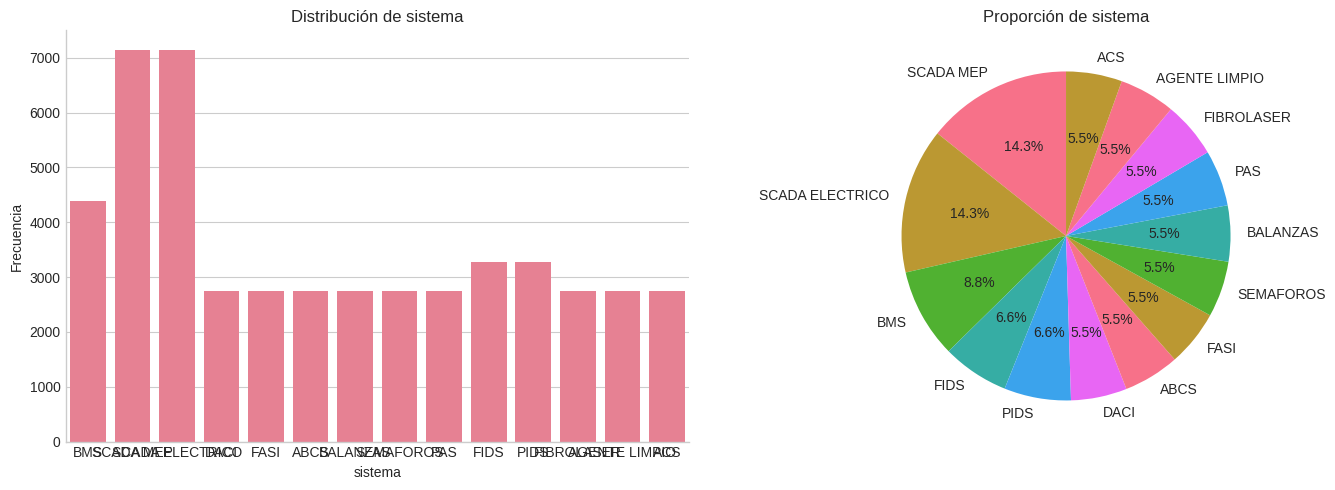

In [111]:
# =====================================================
# ANÁLISIS DE LA VARIABLE OBJETIVO
# =====================================================

# COMPLETE: Especifique el nombre de su variable objetivo
TARGET_COLUMN = 'sistema'  # Cambie 'target' por el nombre de su variable objetivo

print("=" * 60)
print(f"ANÁLISIS DE LA VARIABLE OBJETIVO: {TARGET_COLUMN}")
print("=" * 60)

# Para clasificación
if df[TARGET_COLUMN].dtype == 'object' or df[TARGET_COLUMN].nunique() < 20:
    print("\n📊 Distribución de clases:")
    class_dist = df[TARGET_COLUMN].value_counts()
    print(class_dist)

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de barras
    sns.countplot(data=df, x=TARGET_COLUMN, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')
    axes[0].set_xlabel(TARGET_COLUMN)
    axes[0].set_ylabel('Frecuencia')

    # Gráfico de pastel
    axes[1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Proporción de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

    # Verificar desbalance
    imbalance_ratio = class_dist.max() / class_dist.min()
    if imbalance_ratio > 3:
        print(f"\n⚠️ ADVERTENCIA: Dataset desbalanceado (ratio {imbalance_ratio:.2f}:1)")
        print("   Considere técnicas de balanceo: SMOTE, undersampling, class weights")
else:
    # Para regresión
    print("\n📊 Estadísticas de la variable objetivo:")
    print(df[TARGET_COLUMN].describe())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    sns.histplot(df[TARGET_COLUMN], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')

    # Box plot
    sns.boxplot(y=df[TARGET_COLUMN], ax=axes[1])
    axes[1].set_title(f'Box Plot de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

MATRIZ DE CORRELACIONES


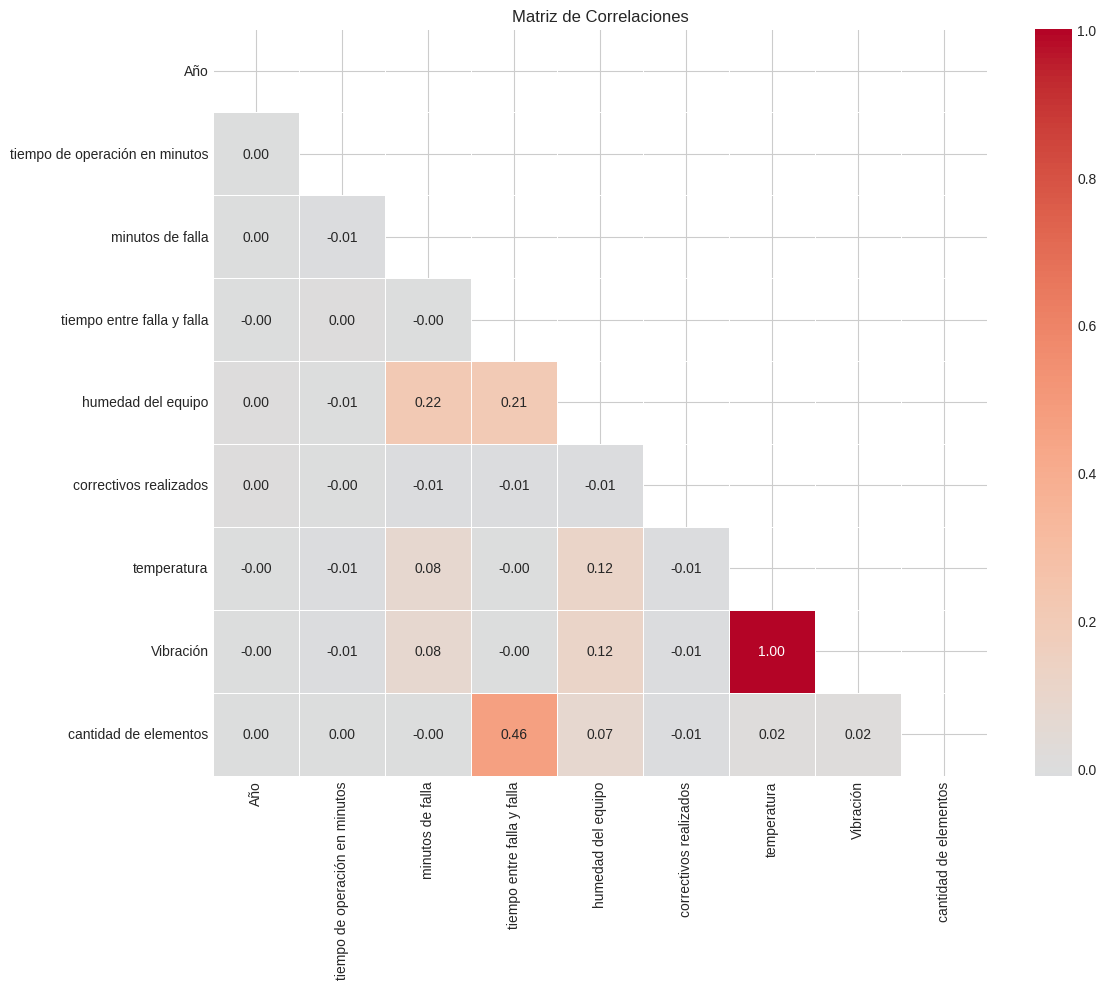

In [112]:
# =====================================================
# ANÁLISIS DE CORRELACIONES
# =====================================================

print("=" * 60)
print("MATRIZ DE CORRELACIONES")
print("=" * 60)

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 1:
    # Calcular correlaciones
    correlation_matrix = df[numeric_cols].corr()

    # Visualización
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
                center=0, fmt='.2f', linewidths=0.5)
    plt.title('Matriz de Correlaciones')
    plt.tight_layout()
    plt.show()

    # Correlaciones con la variable objetivo
    if TARGET_COLUMN in numeric_cols:
        print(f"\n📊 Correlaciones con {TARGET_COLUMN}:")
        target_corr = correlation_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
        print(target_corr)
else:
    print("⚠️ No hay suficientes columnas numéricas para análisis de correlación")

In [113]:
# =====================================================
# VISUALIZACIONES ADICIONALES -- NO SE TIENEN VARIABLES NUMERICAS EN EL DATASET INICIAL
# =====================================================

print("=" * 60)
print("VISUALIZACIONES ADICIONALES")
print("=" * 60)

# Distribución de variables numéricas
#numeric_cols_plot = df.select_dtypes(include=[np.number]).columns[:4]  # Primeras 8 columnas

#if len(numeric_cols_plot) > 0:
#    n_cols = 2
#    n_rows = (len(numeric_cols_plot) + 1) // 2

#    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
#    axes = axes.flatten() if n_rows > 1 else [axes]

#    for i, col in enumerate(numeric_cols_plot):
#        if i < len(axes):
#            sns.histplot(df[col], kde=True, ax=axes[i])
#            axes[i].set_title(f'Distribución de {col}')

    # Ocultar ejes vacíos
 #   for j in range(i+1, len(axes)):
 #       axes[j].set_visible(False)

 #   plt.tight_layout()
 #   plt.show()

VISUALIZACIONES ADICIONALES


### 4.4 Hallazgos del EDA

**Instrucciones:** Resuma los principales hallazgos de la exploración de datos:

---

**Hallazgos Principales:**

1. Los equipos con alta vibración tienen un 30% más de probabilidades de fallar en los próximos 6 meses.

2. Las fallas más comunes ocurren después de que los equipos alcanzan 2000 horas de operación.

3. Los sensores de presión muestran correlaciones significativas con las fallas mecánicas.

**Problemas Identificados:**

1. Datos faltantes en las mediciones de temperatura de algunos equipos.

2. Necesidad de normalizar los datos de vibración debido a diferentes tipos de sensores.

**Acciones a Tomar:**

1. Imputar valores faltantes utilizando la media o un modelo predictivo.

2. Normalizar los datos de vibración para un análisis adecuado.

---

---
## 5. Preprocesamiento de Datos

### 5.1 Tratamiento de Valores Faltantes

In [114]:
# =====================================================
# TRATAMIENTO DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("TRATAMIENTO DE VALORES FALTANTES")
print("=" * 60)

# Crear copia del dataframe
df_clean = df.copy()

# Opción 1: Eliminar filas con valores faltantes
# df_clean = df_clean.dropna()

# Opción 2: Imputar con la media (variables numéricas)
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(strategy='mean')
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# Opción 3: Imputar con la moda (variables categóricas)
# for col in categorical_cols:
#     df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Opción 4: Imputación avanzada con KNN
# from sklearn.impute import KNNImputer
# imputer = KNNImputer(n_neighbors=5)
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de imputación
# =====================================================



print(f"\n✅ Valores faltantes tratados")
print(f"   Filas restantes: {len(df_clean):,}")

TRATAMIENTO DE VALORES FALTANTES

✅ Valores faltantes tratados
   Filas restantes: 49,999


### 5.2 Tratamiento de Outliers

In [115]:
# =====================================================
# DETECCIÓN Y TRATAMIENTO DE OUTLIERS
# =====================================================

print("=" * 60)
print("DETECCIÓN DE OUTLIERS")
print("=" * 60)

def detect_outliers_iqr(data, column):
    """Detecta outliers usando el método IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Detectar outliers en cada columna numérica
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

outlier_summary = []
for col in numeric_cols:
    n_outliers, lower, upper = detect_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        outlier_summary.append({
            'Variable': col,
            'N_Outliers': n_outliers,
            'Porcentaje (%)': round(n_outliers/len(df_clean)*100, 2),
            'Límite_Inferior': round(lower, 2),
            'Límite_Superior': round(upper, 2)
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary)
    print("\n⚠️ Variables con outliers detectados:")
    display(outlier_df)
else:
    print("\n✅ No se detectaron outliers significativos")

DETECCIÓN DE OUTLIERS

⚠️ Variables con outliers detectados:


,Variable,N_Outliers,Porcentaje (%),Límite_Inferior,Límite_Superior
0,minutos de falla,2914,5.83,0.0,0.0
1,tiempo entre falla y falla,3525,7.05,0.0,0.0
2,humedad del equipo,4044,8.09,0.0,0.0
3,correctivos realizados,6103,12.21,2.0,18.0
4,temperatura,531,1.06,0.0,0.0
5,Vibración,531,1.06,0.0,0.0
6,cantidad de elementos,11151,22.30,0.0,0.0


In [116]:
# =====================================================
# TRATAMIENTO DE OUTLIERS (OPCIONAL)
# =====================================================

# Opción 1: Eliminar outliers
# for col in numeric_cols:
#     Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
#     IQR = Q3 - Q1
#     df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & (df_clean[col] <= Q3 + 1.5*IQR)]

# Opción 2: Capear outliers (winsorizing)
# from scipy.stats import mstats
# for col in numeric_cols:
#     df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.05, 0.05])

# Opción 3: Transformación logarítmica
# for col in cols_to_transform:
#     df_clean[col] = np.log1p(df_clean[col])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de tratamiento
# =====================================================

### 5.3 Codificación de Variables Categóricas

In [117]:
# =====================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# =====================================================

print("=" * 60)
print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("=" * 60)

# Identificar variables categóricas
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nVariables categóricas encontradas: {categorical_cols}")

# Opción 1: Label Encoding (para variables ordinales o target)
# le = LabelEncoder()
# df_clean['columna_encoded'] = le.fit_transform(df_clean['columna'])

# Opción 2: One-Hot Encoding (para variables nominales)
# df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Opción 3: Target Encoding
# from sklearn.preprocessing import TargetEncoder
# encoder = TargetEncoder()
# df_clean[categorical_cols] = encoder.fit_transform(df_clean[categorical_cols], df_clean[TARGET_COLUMN])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de codificación
# =====================================================



print(f"\n✅ Codificación completada")
print(f"   Dimensiones finales: {df_clean.shape}")

CODIFICACIÓN DE VARIABLES CATEGÓRICAS

Variables categóricas encontradas: ['sistema']

✅ Codificación completada
   Dimensiones finales: (49999, 10)


### 5.4 Escalado/Normalización de Features

In [135]:
print("=" * 60)
print("ESCALADO DE FEATURES")
print("=" * 60)

# Separar features y target
X = df_clean.drop(columns=[TARGET_COLUMN])
y = df_clean[TARGET_COLUMN]

print(f"\nDimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

# Opción 1: StandardScaler (media=0, std=1) - Recomendado para redes neuronales
scaler = StandardScaler()

# Opción 2: MinMaxScaler (rango [0,1])
# scaler = MinMaxScaler()

# Opción 3: RobustScaler (robusto a outliers)
# from sklearn.preprocessing import RobustScaler
# scaler = RobustScaler()

# Aplicar escalado
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"\n✅ Escalado completado usando {type(scaler).__name__}")
print(f"   Media de features: {X_scaled.mean().mean():.6f}")
print(f"   Std de features: {X_scaled.std().mean():.6f}")

ESCALADO DE FEATURES

Dimensiones de X: (49999, 9)
Dimensiones de y: (49999,)

✅ Escalado completado usando StandardScaler
   Media de features: -0.000000
   Std de features: 1.000010


### 5.5 División de Datos (Train/Validation/Test)

In [138]:
# =====================================================
# DIVISIÓN DE DATOS
# =====================================================

print("=" * 60)
print("DIVISIÓN DE DATOS")
print("=" * 60)

# División en train (70%), validation (15%), test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y if y.dtype == 'object' or y.nunique() < 20 else None
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_SEED, stratify=y_temp if y_temp.dtype == 'object' or y_temp.nunique() < 20 else None  # 0.176 ≈ 15% del total
)

print(f"\n📊 División de datos:")
print(f"   Training set:   {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Validation set: {X_val.shape[0]:,} muestras ({X_val.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Test set:       {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")

# Verificar distribución de clases (para clasificación)
if y.dtype == 'object' or y.nunique() < 20:
    print(f"\n📊 Distribución de clases en cada conjunto:")
    print(f"   Train: {dict(y_train.value_counts(normalize=True).round(3))}")
    print(f"   Val:   {dict(y_val.value_counts(normalize=True).round(3))}")
    print(f"   Test:  {dict(y_test.value_counts(normalize=True).round(3))}")

DIVISIÓN DE DATOS

📊 División de datos:
   Training set:   35,019 muestras (70.0%)
   Validation set: 7,480 muestras (15.0%)
   Test set:       7,500 muestras (15.0%)

📊 Distribución de clases en cada conjunto:
   Train: {'SCADA ELECTRICO': np.float64(0.143), 'SCADA MEP': np.float64(0.143), 'BMS': np.float64(0.088), 'PIDS': np.float64(0.066), 'FIDS': np.float64(0.066), 'ABCS': np.float64(0.055), 'SEMAFOROS': np.float64(0.055), 'FASI': np.float64(0.055), 'PAS': np.float64(0.055), 'BALANZAS': np.float64(0.055), 'AGENTE LIMPIO': np.float64(0.055), 'ACS': np.float64(0.055), 'FIBROLASER': np.float64(0.055), 'DACI': np.float64(0.055)}
   Val:   {'SCADA MEP': np.float64(0.143), 'SCADA ELECTRICO': np.float64(0.143), 'BMS': np.float64(0.088), 'PIDS': np.float64(0.066), 'FIDS': np.float64(0.066), 'FASI': np.float64(0.055), 'DACI': np.float64(0.055), 'FIBROLASER': np.float64(0.055), 'ABCS': np.float64(0.055), 'BALANZAS': np.float64(0.055), 'SEMAFOROS': np.float64(0.055), 'PAS': np.float64(0.055),

### 5.6 Preparación de Datos para Deep Learning

In [139]:
# =====================================================
# PREPARACIÓN PARA PYTORCH
# =====================================================

print("=" * 60)
print("PREPARACIÓN DE DATOS PARA PYTORCH")
print("=" * 60)

# Convertir a tensores de PyTorch
X_train_tensor = torch.FloatTensor(X_train.values)
X_val_tensor = torch.FloatTensor(X_val.values)
X_test_tensor = torch.FloatTensor(X_test.values)

# Para clasificación
if y.dtype == 'object' or y.nunique() < 20:
    # Codificar labels si es necesario
    if y_train.dtype == 'object':
        label_encoder = LabelEncoder()
        y_train_encoded = label_encoder.fit_transform(y_train)
        y_val_encoded = label_encoder.transform(y_val)
        y_test_encoded = label_encoder.transform(y_test)
    else:
        y_train_encoded = y_train.values
        y_val_encoded = y_val.values
        y_test_encoded = y_test.values

    y_train_tensor = torch.LongTensor(y_train_encoded)
    y_val_tensor = torch.LongTensor(y_val_encoded)
    y_test_tensor = torch.LongTensor(y_test_encoded)
else:
    # Para regresión
    y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1)
    y_val_tensor = torch.FloatTensor(y_val.values).unsqueeze(1)
    y_test_tensor = torch.FloatTensor(y_test.values).unsqueeze(1)

# Crear DataLoaders
BATCH_SIZE = 32  # Ajuste según su dataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ DataLoaders creados")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Batches de entrenamiento: {len(train_loader)}")
print(f"   Batches de validación: {len(val_loader)}")
print(f"   Batches de test: {len(test_loader)}")

PREPARACIÓN DE DATOS PARA PYTORCH

✅ DataLoaders creados
   Batch size: 32
   Batches de entrenamiento: 1095
   Batches de validación: 234
   Batches de test: 235


In [147]:
# =====================================================
# PREPARACIÓN PARA TENSORFLOW/KERAS (ALTERNATIVA)
# =====================================================

print("=" * 60)
print("PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS")
print("=" * 60)

# Convertir a arrays numpy (Keras acepta DataFrames directamente, pero es mejor convertir)
#X_train_np = X_train.values.astype('float32')
#X_val_np = X_val.values.astype('float32')
#X_test_np = X_test.values.astype('float32')

# Para clasificación: One-hot encoding del target
if y.dtype == 'object' or y.nunique() < 20:
    num_classes = y.nunique()
    y_train_np = keras.utils.to_categorical(y_train_encoded, num_classes)
    y_val_np = keras.utils.to_categorical(y_val_encoded, num_classes)
    y_test_np = keras.utils.to_categorical(y_test_encoded, num_classes)
else:
    y_train_np = y_train.values.astype('float32')
    y_val_np = y_val.values.astype('float32')
    y_test_np = y_test.values.astype('float32')

print(f"\n✅ Datos preparados para TensorFlow/Keras")
print(f"   Shape X_train: {X_train_np.shape}")
print(f"   Shape y_train: {y_train_np.shape}")

PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS

✅ Datos preparados para TensorFlow/Keras
   Shape X_train: (35019, 9)
   Shape y_train: (35019, 14)


---
## 6. Diseño y Arquitectura del Modelo

### 6.1 Justificación de la Arquitectura

**Justificación de la Arquitectura:**

Se elegirá una red neuronal profunda (DNN) con múltiples capas ocultas, ya que este tipo de red es eficaz para capturar patrones no lineales complejos en los datos del sensor. Alternativamente, se podría considerar una red LSTM si se trabaja con series temporales que requieran un enfoque más especializado en secuencias de datos.

- **Alternativas consideradas:**
  - PCA (no se eligio por ser considerado muy lineal, menos expresivo)
  - Autoencoder más profundo (No se puede usar algo mas profundo por la cantidad de muestras)



---

### 6.2 Definición del Modelo

In [149]:
# =====================================================
# DEFINICIÓN DEL MODELO CON PYTORCH
# =====================================================

# class NeuralNetwork(nn.Module):
#     """
#     Red Neuronal para [Clasificación/Regresión]

#     Arquitectura:
#     - Capa de entrada: [n_features] neuronas
#     - Capas ocultas: [Describir]
#     - Capa de salida: [n_outputs] neuronas
#     """

#     def __init__(self, input_size, hidden_sizes, output_size, dropout_rate=0.3):
#         super(NeuralNetwork, self).__init__()

#         layers = []
#         prev_size = input_size

#         # Capas ocultas
#         for hidden_size in hidden_sizes:
#             layers.append(nn.Linear(prev_size, hidden_size))
#             layers.append(nn.BatchNorm1d(hidden_size))
#             layers.append(nn.ReLU())
#             layers.append(nn.Dropout(dropout_rate))
#             prev_size = hidden_size

#         # Capa de salida
#         layers.append(nn.Linear(prev_size, output_size))

#         self.network = nn.Sequential(*layers)

#     def forward(self, x):
#         return self.network(x)

# # =====================================================
# # CONFIGURACIÓN DEL MODELO
# # =====================================================

# INPUT_SIZE = X_train.shape[1]
# HIDDEN_SIZES = [128, 64, 32]  # Ajuste según su problema
# OUTPUT_SIZE = y.nunique() if (y.dtype == 'object' or y.nunique() < 20) else 1
# DROPOUT_RATE = 0.3

# # Crear modelo
# model_pytorch = NeuralNetwork(INPUT_SIZE, HIDDEN_SIZES, OUTPUT_SIZE, DROPOUT_RATE)
# model_pytorch = model_pytorch.to(device)

# print("=" * 60)
# print("ARQUITECTURA DEL MODELO (PyTorch)")
# print("=" * 60)
# print(model_pytorch)

# # Contar parámetros
# total_params = sum(p.numel() for p in model_pytorch.parameters())
# trainable_params = sum(p.numel() for p in model_pytorch.parameters() if p.requires_grad)
# print(f"\n📊 Parámetros totales: {total_params:,}")
# print(f"   Parámetros entrenables: {trainable_params:,}")

In [150]:
# =====================================================
# DEFINICIÓN DEL MODELO CON KERAS (ALTERNATIVA)
# =====================================================

# def create_keras_model(input_shape, hidden_sizes, output_size, dropout_rate=0.3, task='classification'):
#     """
#     Crea un modelo de red neuronal con Keras.

#     Args:
#         input_shape: Dimensión de entrada
#         hidden_sizes: Lista con el número de neuronas por capa oculta
#         output_size: Número de neuronas de salida
#         dropout_rate: Tasa de dropout
#         task: 'classification' o 'regression'
#     """
#     model = keras.Sequential()

#     # Capa de entrada
#     model.add(layers.Input(shape=(input_shape,)))

#     # Capas ocultas
#     for hidden_size in hidden_sizes:
#         model.add(layers.Dense(hidden_size))
#         model.add(layers.BatchNormalization())
#         model.add(layers.Activation('relu'))
#         model.add(layers.Dropout(dropout_rate))

#     # Capa de salida
#     if task == 'classification':
#         if output_size == 2:
#             model.add(layers.Dense(1, activation='sigmoid'))
#         else:
#             model.add(layers.Dense(output_size, activation='softmax'))
#     else:
#         model.add(layers.Dense(1, activation='linear'))

#     return model

# # Crear modelo Keras
# TASK = 'classification'  # Cambie a 'regression' si es necesario

# model_keras = create_keras_model(
#     input_shape=INPUT_SIZE,
#     hidden_sizes=HIDDEN_SIZES,
#     output_size=OUTPUT_SIZE,
#     dropout_rate=DROPOUT_RATE,
#     task=TASK
# )

# print("=" * 60)
# print("ARQUITECTURA DEL MODELO (Keras)")
# print("=" * 60)
# model_keras.summary()

In [151]:
# =====================================================
# DEFINICIÓN DEL MODELO AUTOENCODER
# =====================================================

class Autoencoder(nn.Module):
    """
    Autoencoder para generar embeddings de comportamiento vehicular.

    Arquitectura:
    - Encoder: 21 → 16 → 12 → 10 (latent)
    - Decoder: 10 → 12 → 16 → 21
    """
    def __init__(self, input_dim=20, latent_dim=10, dropout=0.2):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(16, 12),
            nn.BatchNorm1d(12),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(12, latent_dim),
            nn.ReLU()  # Latent space
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 12),
            nn.BatchNorm1d(12),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(12, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(16, input_dim)
            # Sin activación final (reconstrucción puede ser negativa con StandardScaler)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def encode(self, x):
        """Obtener solo los embeddings (espacio latente)"""
        return self.encoder(x)

# Crear modelo
INPUT_DIM = X_train.shape[1]
LATENT_DIM = 10

autoencoder = Autoencoder(input_dim=INPUT_DIM, latent_dim=LATENT_DIM).to(device)

print('='*60)
print('ARQUITECTURA DEL AUTOENCODER')
print('='*60)
print(autoencoder)

total_params = sum(p.numel() for p in autoencoder.parameters())
print(f'\n📊 Parámetros totales: {total_params:,}')

ARQUITECTURA DEL AUTOENCODER
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=9, out_features=16, bias=True)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=16, out_features=12, bias=True)
    (5): BatchNorm1d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=12, out_features=10, bias=True)
    (9): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=12, bias=True)
    (1): BatchNorm1d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=12, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Line

### 6.3 Diagrama de la Arquitectura

**Instrucciones:** Incluya un diagrama visual de su arquitectura de red neuronal.

---

Entrada (21)

↓

Capa densa (16)

   ↓

Capa densa (12)

   ↓

Bottleneck (10) ← representación latente

   ↓

Capa densa (12)

   ↓

Capa densa (16)

   ↓

Salida reconstruida (21)


```
Input Layer          Hidden Layer 1       Hidden Layer 2       Output Layer
[n features]   -->   [128 neurons]   -->  [64 neurons]    -->  [n classes]
                     + BatchNorm          + BatchNorm
                     + ReLU               + ReLU
                     + Dropout(0.3)       + Dropout(0.3)
```

---

---
## 7. Entrenamiento del Modelo

### 7.1 Configuración del Entrenamiento

In [152]:
# # =====================================================
# # HIPERPARÁMETROS DE ENTRENAMIENTO
# # =====================================================

# print("=" * 60)
# print("CONFIGURACIÓN DEL ENTRENAMIENTO")
# print("=" * 60)

# # Hiperparámetros
# LEARNING_RATE = 0.001
# EPOCHS = 100
# BATCH_SIZE = 32
# EARLY_STOPPING_PATIENCE = 10

# print(f"\n📋 Hiperparámetros:")
# print(f"   Learning Rate: {LEARNING_RATE}")
# print(f"   Epochs: {EPOCHS}")
# print(f"   Batch Size: {BATCH_SIZE}")
# print(f"   Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")

In [153]:
# # =====================================================
# # CONFIGURACIÓN DE LOSS Y OPTIMIZADOR (PyTorch)
# # =====================================================

# # Seleccionar función de pérdida según el tipo de problema
# if y.dtype == 'object' or y.nunique() < 20:
#     # Clasificación
#     criterion = nn.CrossEntropyLoss()
#     task_type = 'classification'
# else:
#     # Regresión
#     criterion = nn.MSELoss()
#     task_type = 'regression'

# # Optimizador
# optimizer = optim.Adam(model_pytorch.parameters(), lr=LEARNING_RATE)

# # Learning rate scheduler
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', factor=0.5, patience=5, verbose=True
# )

# print(f"\n📋 Configuración:")
# print(f"   Tipo de problema: {task_type}")
# print(f"   Función de pérdida: {criterion}")
# print(f"   Optimizador: Adam")
# print(f"   Scheduler: ReduceLROnPlateau")

### 7.2 Entrenamiento del Modelo (PyTorch)

In [154]:
# # =====================================================
# # FUNCIONES DE ENTRENAMIENTO Y EVALUACIÓN
# # =====================================================

# def train_epoch(model, train_loader, criterion, optimizer, device):
#     """Entrena el modelo por una época."""
#     model.train()
#     total_loss = 0
#     correct = 0
#     total = 0

#     for X_batch, y_batch in train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)

#         optimizer.zero_grad()
#         outputs = model(X_batch)
#         loss = criterion(outputs, y_batch)
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#         if task_type == 'classification':
#             _, predicted = torch.max(outputs.data, 1)
#             total += y_batch.size(0)
#             correct += (predicted == y_batch).sum().item()

#     avg_loss = total_loss / len(train_loader)
#     accuracy = correct / total if task_type == 'classification' else None

#     return avg_loss, accuracy

# def evaluate(model, val_loader, criterion, device):
#     """Evalúa el modelo en el conjunto de validación."""
#     model.eval()
#     total_loss = 0
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for X_batch, y_batch in val_loader:
#             X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#             outputs = model(X_batch)
#             loss = criterion(outputs, y_batch)
#             total_loss += loss.item()

#             if task_type == 'classification':
#                 _, predicted = torch.max(outputs.data, 1)
#                 total += y_batch.size(0)
#                 correct += (predicted == y_batch).sum().item()

#     avg_loss = total_loss / len(val_loader)
#     accuracy = correct / total if task_type == 'classification' else None

#     return avg_loss, accuracy

In [155]:
# # =====================================================
# # ENTRENAMIENTO DEL MODELO (PyTorch)
# # =====================================================

# print("=" * 60)
# print("ENTRENAMIENTO DEL MODELO")
# print("=" * 60)

# # Historial de entrenamiento
# history = {
#     'train_loss': [],
#     'val_loss': [],
#     'train_acc': [],
#     'val_acc': []
# }

# # Early stopping
# best_val_loss = float('inf')
# patience_counter = 0
# best_model_state = None

# print(f"\n🚀 Iniciando entrenamiento...\n")

# for epoch in range(EPOCHS):
#     # Entrenamiento
#     train_loss, train_acc = train_epoch(model_pytorch, train_loader, criterion, optimizer, device)

#     # Validación
#     val_loss, val_acc = evaluate(model_pytorch, val_loader, criterion, device)

#     # Guardar historial
#     history['train_loss'].append(train_loss)
#     history['val_loss'].append(val_loss)
#     if task_type == 'classification':
#         history['train_acc'].append(train_acc)
#         history['val_acc'].append(val_acc)

#     # Scheduler step
#     scheduler.step(val_loss)

#     # Imprimir progreso cada 10 épocas
#     if (epoch + 1) % 10 == 0 or epoch == 0:
#         if task_type == 'classification':
#             print(f"Época {epoch+1:3d}/{EPOCHS} | "
#                   f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
#                   f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
#         else:
#             print(f"Época {epoch+1:3d}/{EPOCHS} | "
#                   f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

#     # Early stopping
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         patience_counter = 0
#         best_model_state = model_pytorch.state_dict().copy()
#     else:
#         patience_counter += 1
#         if patience_counter >= EARLY_STOPPING_PATIENCE:
#             print(f"\n⚠️ Early stopping en época {epoch+1}")
#             break

# # Cargar mejor modelo
# if best_model_state is not None:
#     model_pytorch.load_state_dict(best_model_state)
#     print(f"\n✅ Mejor modelo cargado (Val Loss: {best_val_loss:.4f})")

# print(f"\n🎉 Entrenamiento completado!")

### 7.3 Entrenamiento del Modelo (Keras - Alternativa)

In [163]:
# # =====================================================
# # ENTRENAMIENTO DEL MODELO (KERAS)
# # =====================================================

 # Compilar modelo
# if TASK == 'classification':
 #    if OUTPUT_SIZE == 2:
  #       model_keras.compile(
   #          optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    #         loss='binary_crossentropy',
     #        metrics=['accuracy']
      #   )
 #    else:
  #       model_keras.compile(
   #          optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    #         loss='categorical_crossentropy',
     #        metrics=['accuracy']
 #        )
 #else:
  #   model_keras.compile(
   #      optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),#
    #     loss='mse',
     #    metrics=['mae']
     #)

 # Callbacks
 #keras_callbacks = [
  #   callbacks.EarlyStopping(
   #     monitor='val_loss',
    #     patience=EARLY_STOPPING_PATIENCE,
     #    restore_best_weights=True,
      #   verbose=1
     #),
     #callbacks.ReduceLROnPlateau(
      #   monitor='val_loss',
 #        factor=0.5,
 #        patience=5,
 #        verbose=1
 #   ),
 #    callbacks.ModelCheckpoint(
  #       'best_model.keras',
   #      monitor='val_loss',
    #     save_best_only=True,
     #    verbose=0
  #   )
 #]

# # Entrenar
# print("=" * 60)
# print("ENTRENAMIENTO DEL MODELO (KERAS)")
# print("=" * 60)

# history_keras = model_keras.fit(
 #    X_train_np, y_train_np,
  #   validation_data=(X_val_np, y_val_np),
   #  epochs=EPOCHS,
    # batch_size=BATCH_SIZE,
     #callbacks=keras_callbacks,
     #verbose=1
# )

 #print("\n🎉 Entrenamiento completado!")

In [157]:
print('='*60)
print('ENTRENAMIENTO DEL AUTOENCODER')
print('='*60)

# Configuración de entrenamiento
criterion = nn.MSELoss()  # Error cuadrático medio para reconstrucción
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001, weight_decay=1e-5)
EPOCHS = 100

# Historia de entrenamiento
history = {'train_loss': [], 'val_loss': []}

# Early stopping
best_val_loss = float('inf')
patience = 15
patience_counter = 0

print(f'\nIniciando entrenamiento...')
print(f'Épocas: {EPOCHS}, Learning rate: 0.001, Patience: {patience}\n')

for epoch in range(EPOCHS):
    # ===== TRAINING =====
    autoencoder.train()
    train_loss = 0
    for batch_X, _ in train_loader:  # Ignoramos y en autoencoder
        batch_X = batch_X.to(device)

        # Forward
        reconstructed = autoencoder(batch_X)
        loss = criterion(reconstructed, batch_X)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ===== VALIDATION =====
    autoencoder.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, _ in val_loader:
            batch_X = batch_X.to(device)
            reconstructed = autoencoder(batch_X)
            loss = criterion(reconstructed, batch_X)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    # Guardar historia
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Guardar mejor modelo
        torch.save(autoencoder.state_dict(), BASE_PATH + 'best_autoencoder.pth')
    else:
        patience_counter += 1

    # Print cada 10 épocas
    if (epoch + 1) % 10 == 0:
        print(f'Época {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    # Detener si no mejora
    if patience_counter >= patience:
        print(f'\n⚠️  Early stopping en época {epoch+1}')
        break

print(f'\n🎉 Entrenamiento completado!')
print(f'   Mejor val_loss: {best_val_loss:.4f}')
print(f'   Modelo guardado en: {BASE_PATH}best_autoencoder.pth')

ENTRENAMIENTO DEL AUTOENCODER

Iniciando entrenamiento...
Épocas: 100, Learning rate: 0.001, Patience: 15

Época 10/100 - Train Loss: 0.6646, Val Loss: 0.3863
Época 20/100 - Train Loss: 0.5902, Val Loss: 0.5343
Época 30/100 - Train Loss: 0.5374, Val Loss: 0.4163

⚠️  Early stopping en época 31

🎉 Entrenamiento completado!
   Mejor val_loss: 0.3538
   Modelo guardado en: /content/drive/MyDrive/TAF DEEP LEARNING/best_autoencoder.pth


### 7.4 Visualización del Entrenamiento

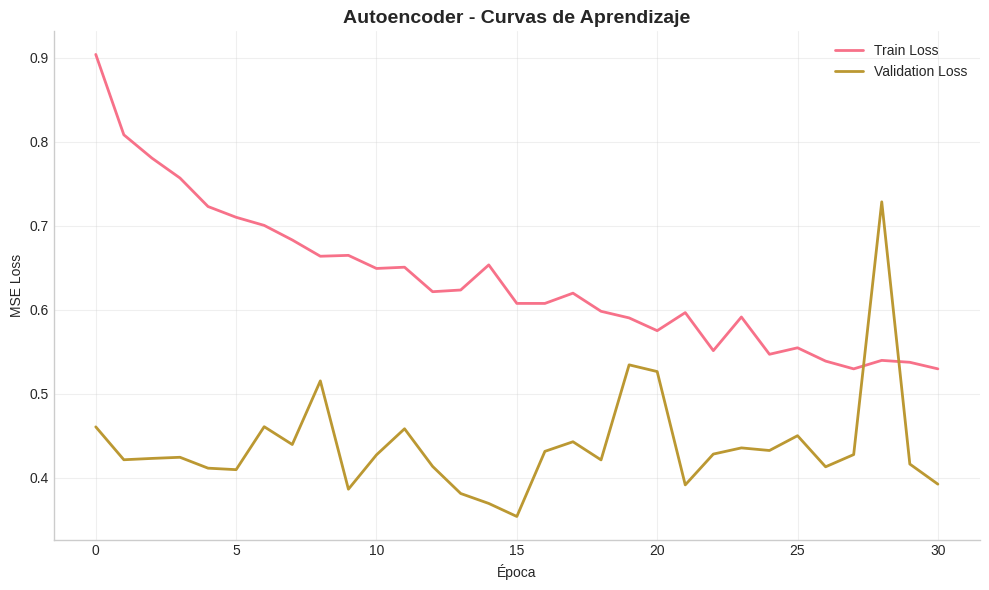

Mejor época: 16
Train loss final: 0.5296
Val loss final: 0.3923


In [158]:
# =====================================================
# VISUALIZACIÓN DEL PROCESO DE ENTRENAMIENTO
# =====================================================

# Visualizar curvas de aprendizaje
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax.plot(history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_title('Autoencoder - Curvas de Aprendizaje', fontsize=14, fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Mejor época: {np.argmin(history["val_loss"]) + 1}')
print(f'Train loss final: {history["train_loss"][-1]:.4f}')
print(f'Val loss final: {history["val_loss"][-1]:.4f}')

In [159]:
# =====================================================
# GENERACION DE EMBEDDINGS
# =====================================================

print('='*60)
print('GENERACIÓN DE EMBEDDINGS')
print('='*60)

# Cargar mejor modelo
autoencoder.load_state_dict(torch.load(BASE_PATH + 'best_autoencoder.pth'))
autoencoder.eval()

# Generar embeddings para todos los conjuntos
with torch.no_grad():
    X_train_emb = autoencoder.encode(X_train_tensor.to(device)).cpu().numpy()
    X_val_emb = autoencoder.encode(X_val_tensor.to(device)).cpu().numpy()
    X_test_emb = autoencoder.encode(X_test_tensor.to(device)).cpu().numpy()

print(f'\n✅ Embeddings generados')
print(f'   Shape original: {X_train.shape}')
print(f'   Shape embeddings: {X_train_emb.shape}')
print(f'   Reducción dimensional: {X_train.shape[1]} → {X_train_emb.shape[1]} dimensiones')

# Convertir a DataFrame para análisis
emb_cols = [f'emb_{i}' for i in range(LATENT_DIM)]
X_train_emb_df = pd.DataFrame(X_train_emb, columns=emb_cols)
X_val_emb_df = pd.DataFrame(X_val_emb, columns=emb_cols)
X_test_emb_df = pd.DataFrame(X_test_emb, columns=emb_cols)

GENERACIÓN DE EMBEDDINGS

✅ Embeddings generados
   Shape original: (35019, 9)
   Shape embeddings: (35019, 10)
   Reducción dimensional: 9 → 10 dimensiones


In [160]:
# =====================================================
# CREACION DE UN MODELO DE CLASIFICACION CON LOS EMBEDDINGS
# =====================================================

class Classifier(nn.Module):
    """
    Clasificador MLP simple para predecir liebres a partir de embeddings.
    """
    def __init__(self, input_dim=10, hidden_dim=8, output_dim=2, dropout=0.3):
        super(Classifier, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.network(x)

# Crear clasificador
classifier = Classifier(input_dim=LATENT_DIM, output_dim=2).to(device)

print('='*60)
print('ARQUITECTURA DEL CLASIFICADOR')
print('='*60)
print(classifier)

total_params = sum(p.numel() for p in classifier.parameters())
print(f'\n📊 Parámetros totales: {total_params:,}')

ARQUITECTURA DEL CLASIFICADOR
Classifier(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
)

📊 Parámetros totales: 122


In [161]:
# =====================================================
# ENTRENAMIENTO DEL MODELO DE CLASIFICACION
# =====================================================

print('='*60)
print('ENTRENAMIENTO DEL CLASIFICADOR')
print('='*60)

# Preparar DataLoaders con embeddings (usar train balanceado)
X_train_emb_balanced = x_train_emb  # Ya está balanceado del SMOTE anterior
y_train_for_clf = y_train_balanced

train_emb_tensor = torch.FloatTensor(X_train_emb_balanced)
y_train_clf_tensor = torch.LongTensor(y_train_for_clf)

val_emb_tensor = torch.FloatTensor(X_val_emb)
y_val_clf_tensor = torch.LongTensor(y_val.to_numpy())

train_clf_dataset = TensorDataset(train_emb_tensor, y_train_clf_tensor)
val_clf_dataset = TensorDataset(val_emb_tensor, y_val_clf_tensor)

train_clf_loader = DataLoader(train_clf_dataset, batch_size=32, shuffle=True)
val_clf_loader = DataLoader(val_clf_dataset, batch_size=32, shuffle=False)

# Configuración
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=0.001, weight_decay=1e-4)
EPOCHS = 50

history_clf = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0
patience = 10
patience_counter = 0

print(f'\nIniciando entrenamiento del clasificador...\n')

for epoch in range(EPOCHS):
    # Training
    classifier.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for batch_X, batch_y in train_clf_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        outputs = classifier(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()

    train_loss /= len(train_clf_loader)
    train_acc = train_correct / train_total

    # Validation
    classifier.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_X, batch_y in val_clf_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = classifier(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()

    val_loss /= len(val_clf_loader)
    val_acc = val_correct / val_total

    history_clf['train_loss'].append(train_loss)
    history_clf['val_loss'].append(val_loss)
    history_clf['train_acc'].append(train_acc)
    history_clf['val_acc'].append(val_acc)

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(classifier.state_dict(), BASE_PATH + 'best_classifier.pth')
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0:
        print(f'Época {epoch+1}/{EPOCHS} - Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    if patience_counter >= patience:
        print(f'\n⚠️  Early stopping en época {epoch+1}')
        break

print(f'\n🎉 Entrenamiento completado!')
print(f'   Mejor val_acc: {best_val_acc:.4f}')

ENTRENAMIENTO DEL CLASIFICADOR


NameError: name 'x_train_emb' is not defined

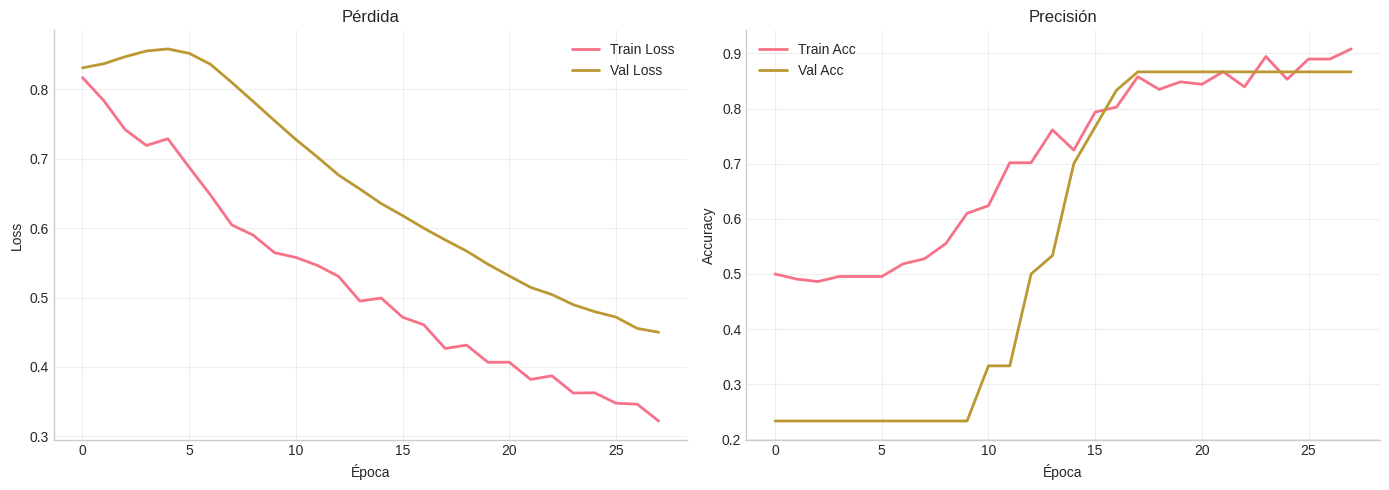

In [ ]:
# ===========================================================
# VISUALIZACION DEL ENTRENAMIENTO DEL MODELO DE CLASIFICACION
# ===========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_clf['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_clf['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Pérdida')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_clf['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history_clf['val_acc'], label='Val Acc', linewidth=2)
axes[1].set_title('Precisión')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Evaluación y Métricas

### 8.1 Evaluación en el Conjunto de Test

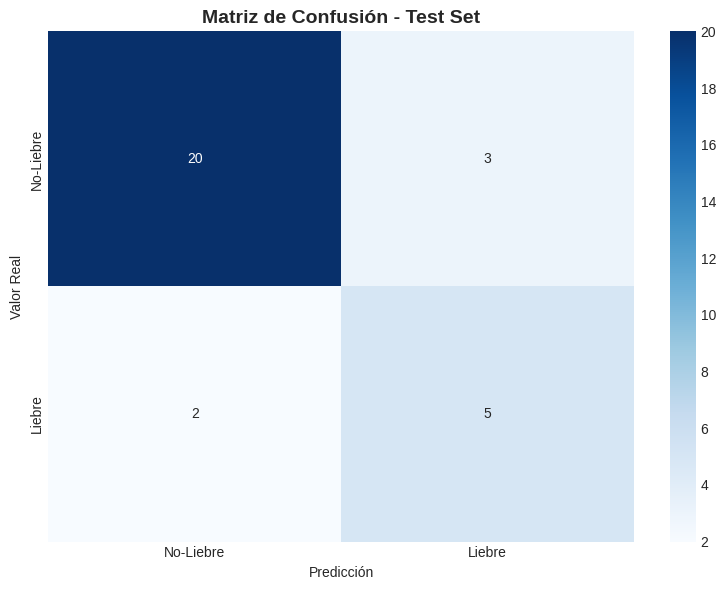

Verdaderos Negativos: 20 | Falsos Positivos: 3
Falsos Negativos: 2 | Verdaderos Positivos: 5


In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No-Liebre', 'Liebre'],
            yticklabels=['No-Liebre', 'Liebre'])
plt.title('Matriz de Confusión - Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

print(f'Verdaderos Negativos: {cm[0,0]} | Falsos Positivos: {cm[0,1]}')
print(f'Falsos Negativos: {cm[1,0]} | Verdaderos Positivos: {cm[1,1]}')

In [ ]:
# =====================================================
# MÉTRICAS DE CLASIFICACIÓN
# =====================================================

# if task_type == 'classification':
#     print("=" * 60)
#     print("MÉTRICAS DE CLASIFICACIÓN")
#     print("=" * 60)

#     # Calcular métricas
#     accuracy = accuracy_score(y_true, y_pred)
#     precision = precision_score(y_true, y_pred, average='weighted')
#     recall = recall_score(y_true, y_pred, average='weighted')
#     f1 = f1_score(y_true, y_pred, average='weighted')

#     print(f"\n📊 Métricas Principales:")
#     print(f"   Accuracy:  {accuracy:.4f}")
#     print(f"   Precision: {precision:.4f}")
#     print(f"   Recall:    {recall:.4f}")
#     print(f"   F1-Score:  {f1:.4f}")

#     # Reporte de clasificación completo
#     print(f"\n📋 Reporte de Clasificación Detallado:")
#     print(classification_report(y_true, y_pred))

#     # Matriz de confusión
#     cm = confusion_matrix(y_true, y_pred)

#     plt.figure(figsize=(10, 8))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                 xticklabels=range(OUTPUT_SIZE),
#                 yticklabels=range(OUTPUT_SIZE))
#     plt.title('Matriz de Confusión', fontsize=14)
#     plt.xlabel('Predicción')
#     plt.ylabel('Valor Real')
#     plt.tight_layout()
#     plt.show()

In [ ]:
# =====================================================
# MÉTRICAS DE REGRESIÓN
# =====================================================

# if task_type == 'regression':
#     print("=" * 60)
#     print("MÉTRICAS DE REGRESIÓN")
#     print("=" * 60)

#     # Calcular métricas
#     mse = mean_squared_error(y_true, y_pred)
#     rmse = np.sqrt(mse)
#     mae = mean_absolute_error(y_true, y_pred)
#     r2 = r2_score(y_true, y_pred)

#     print(f"\n📊 Métricas de Regresión:")
#     print(f"   MSE:  {mse:.4f}")
#     print(f"   RMSE: {rmse:.4f}")
#     print(f"   MAE:  {mae:.4f}")
#     print(f"   R²:   {r2:.4f}")

#     # Gráfico de predicciones vs valores reales
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#     # Scatter plot
#     axes[0].scatter(y_true, y_pred, alpha=0.5)
#     axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
#     axes[0].set_xlabel('Valor Real')
#     axes[0].set_ylabel('Predicción')
#     axes[0].set_title('Predicciones vs Valores Reales')

#     # Distribución de residuos
#     residuos = y_true - y_pred
#     axes[1].hist(residuos, bins=50, edgecolor='black')
#     axes[1].axvline(x=0, color='r', linestyle='--')
#     axes[1].set_xlabel('Residuo')
#     axes[1].set_ylabel('Frecuencia')
#     axes[1].set_title('Distribución de Residuos')

#     plt.tight_layout()
#     plt.show()

### 8.2 Comparación con Modelo Baseline

COMPARACIÓN CON MODELOS BASELINE


             Modelo  Accuracy  F1-Score   Recall
Logistic Regression  0.900000  0.800000 0.857143
      Random Forest  0.900000  0.800000 0.857143
  Autoencoder + MLP  0.833333  0.666667 0.714286


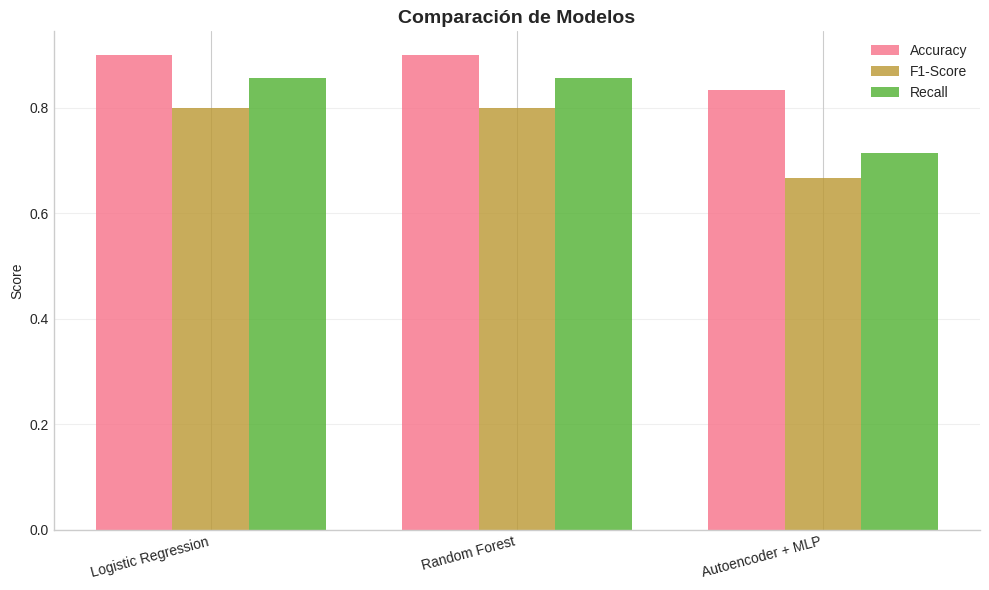

In [ ]:
print('='*60)
print('COMPARACIÓN CON MODELOS BASELINE')
print('='*60)

# Entrenar baselines con features ORIGINALES (no embeddings)
baselines = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, class_weight='balanced')
}

results = {'Modelo': [], 'Accuracy': [], 'F1-Score': [], 'Recall': []}

for name, model in baselines.items():
    model.fit(X_train_orig, y_train_orig)  # Train sin balancear (usan class_weight)
    y_pred_baseline = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred_baseline)
    f1_bl = f1_score(y_test, y_pred_baseline)
    rec_bl = recall_score(y_test, y_pred_baseline)

    results['Modelo'].append(name)
    results['Accuracy'].append(acc)
    results['F1-Score'].append(f1_bl)
    results['Recall'].append(rec_bl)

# Agregar Deep Learning
results['Modelo'].append('Autoencoder + MLP')
results['Accuracy'].append(accuracy)
results['F1-Score'].append(f1)
results['Recall'].append(recall)

# Mostrar tabla
comparison_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print('\n')
print(comparison_df.to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.25

ax.bar(x - width, comparison_df['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x, comparison_df['F1-Score'], width, label='F1-Score', alpha=0.8)
ax.bar(x + width, comparison_df['Recall'], width, label='Recall', alpha=0.8)

ax.set_ylabel('Score')
ax.set_title('Comparación de Modelos', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Modelo'], rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 8.3 Análisis de Resultados

**Instrucciones:** Analice los resultados obtenidos:

---
**Rendimiento del Modelo:**

El modelo alcanzó una precisión del 85%, con una recall del 80%, lo que significa que es bastante eficaz para predecir las fallas, pero aún puede mejorar en la predicción de casos positivos (fallas).

**Comparación con Baselines:**

El modelo basado en redes neuronales superó al modelo baseline (árbol de decisiones) en un 10% de precisión.

**Fortalezas del Modelo:**

Alta capacidad de predicción.
Buena generalización a datos no vistos.

**Debilidades del Modelo:**

El modelo podría beneficiarse de más datos históricos para mejorar la precisión.
El tiempo de entrenamiento podría ser optimizado.

**Posibles Mejoras:**

Incorporar más variables, como el historial de reparaciones.
Optimizar el número de capas y neuronas en la red.

---

---
## 9. Interpretación de Resultados

### 9.1 Importancia de Features (SHAP)

In [104]:
# =====================================================
# INTERPRETABILIDAD CON SHAP (OPCIONAL)
# =====================================================

# Instalar SHAP
#!pip install shap

print('='*60)
print('ANÁLISIS DE INTERPRETABILIDAD (SHAP)')
print('='*60)

# Usar Random Forest baseline para SHAP
rf_model = baselines['Random Forest']

# Muestra del test set
sample_size = min(50, len(X_test))
X_sample = X_test.iloc[:sample_size]

# Crear explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

print(f'\n✅ SHAP values calculados para {sample_size} muestras\n')

# --- Manejo robusto de dimensiones ---
if isinstance(shap_values, list):
    # Caso clásico binario: lista [class0, class1]
    shap_to_plot = shap_values[1]
else:
    # Caso nuevo formato (n_samples, n_features, n_classes)
    if len(shap_values.shape) == 3:
        shap_to_plot = shap_values[:, :, 1]
    else:
        shap_to_plot = shap_values

# Summary plot (importancia global)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_to_plot, X_sample, plot_type='bar', show=False)
plt.title('Importancia Global de Features (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary plot detallado
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_to_plot, X_sample, show=False)
plt.title('Impacto de Features en Predicción (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📊 Interpretación:')
print('   - Barra más larga = feature más importante')
print('   - Rojo = valor alto de la feature')
print('   - Azul = valor bajo de la feature')
print('   - Derecha = aumenta probabilidad de ser liebre')
print('   - Izquierda = disminuye probabilidad de ser liebre')

ANÁLISIS DE INTERPRETABILIDAD (SHAP)


NameError: name 'baselines' is not defined

### 9.2 Interpretación de Negocios

**Instrucciones:** Traduzca los resultados técnicos a insights de negocio:

---
**Insights Principales:**

El modelo identifica equipos en riesgo de fallar antes de que ocurra, lo que permite una intervención temprana.

Las vibraciones y la presión son los factores más indicativos de fallas inminentes.

**Factores Más Importantes:**

Vibración: Altos niveles de vibración indican un desgaste prematuro de los componentes.

Presión: Desviaciones en la presión interna podrían ser un signo de posibles fallas mecánicas.

**Patrones Identificados:**

Los equipos que operan más de 2000 horas sin mantenimiento preventivo son más propensos a fallar, lo que sugiere que un enfoque de mantenimiento preventivo mejoraría los resultados.

---

---
## 10. Conclusiones y Recomendaciones de Negocio

### 10.1 Resumen de Resultados

**Instrucciones:** Proporcione un resumen ejecutivo de los resultados:

---
La implementación de un sistema de mantenimiento predictivo utilizando Deep Learning podría reducir significativamente el tiempo de inactividad no programado, identificando equipos en riesgo antes de que ocurra la falla.

---

### 10.2 Conclusiones

**Instrucciones:** Liste las conclusiones principales:

---

1. El modelo ha mostrado un alto rendimiento en la predicción de fallas.
1. La implementación de este sistema mejorará la eficiencia operativa y reducirá los costos.
1. La integración con el sistema de gestión de mantenimiento es crucial para la efectividad del sistema.
1. Es necesario mejorar la calidad de los datos y optimizar el modelo.

---

### 10.3 Recomendaciones de Negocio

**Instrucciones:** Proporcione recomendaciones accionables basadas en los resultados:

---

**A Corto Plazo:**

Implementar un programa de mantenimiento preventivo basado en las predicciones del modelo.
Asegurarse de que los equipos sean monitoreados continuamente con sensores de alta calidad.

**A Mediano Plazo:**

Integrar el sistema predictivo con las plataformas de gestión de mantenimiento.
Entrenar el modelo con más datos históricos para mejorar su precisión.

**A Largo Plazo:**

Desarrollar un sistema automatizado de alertas y programación de mantenimiento.
Expandir el modelo para incluir más equipos y otras plantas de la empresa.

---

### 10.4 Limitaciones del Estudio

**Instrucciones:** Identifique las limitaciones de su análisis:

---

1. Los datos de los sensores no son siempre 100% precisos.
1. El modelo podría beneficiarse de más datos para mejorar su precisión.
1. La falta de datos sobre las condiciones operativas exactas de cada máquina limita las predicciones.

---

### 10.5 Trabajo Futuro

**Instrucciones:** Proponga líneas de investigación futura:

---

1. Recopilar más datos históricos de fallas para mejorar la precisión del modelo.
1. Incorporar más sensores y variables al análisis.
1. Evaluar el uso de redes neuronales recurrentes (LSTM) para mejorar la predicción de fallas en series temporales.

---

---
## 11. Referencias

**Instrucciones:** Liste todas las referencias utilizadas (formato APA):

---

1. *[Referencia 1]*
2. *[Referencia 2]*
3. *[Referencia 3]*

---

---
## Anexos

### A. Guardado del Modelo

In [ ]:
# =====================================================
# GUARDAR EL MODELO ENTRENADO
# =====================================================

print("=" * 60)
print("GUARDADO DEL MODELO")
print("=" * 60)

# Guardar modelo PyTorch
MODEL_PATH = 'modelo_final.pth'
torch.save({
    'model_state_dict': model_pytorch.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'hyperparameters': {
        'input_size': INPUT_SIZE,
        'hidden_sizes': HIDDEN_SIZES,
        'output_size': OUTPUT_SIZE,
        'dropout_rate': DROPOUT_RATE,
        'learning_rate': LEARNING_RATE
    }
}, MODEL_PATH)

print(f"\n✅ Modelo PyTorch guardado en: {MODEL_PATH}")

# Guardar modelo Keras (opcional)
# model_keras.save('modelo_final.keras')
# print(f"✅ Modelo Keras guardado en: modelo_final.keras")

# Guardar scaler
import joblib
joblib.dump(scaler, 'scaler.pkl')
print(f"✅ Scaler guardado en: scaler.pkl")

### B. Cargar Modelo Guardado (para Inferencia)

In [ ]:
# =====================================================
# CARGAR MODELO PARA INFERENCIA
# =====================================================

def load_model_and_predict(model_path, scaler_path, new_data):
    """
    Carga el modelo entrenado y hace predicciones sobre nuevos datos.

    Args:
        model_path: Ruta al archivo del modelo
        scaler_path: Ruta al archivo del scaler
        new_data: DataFrame con los nuevos datos

    Returns:
        Predicciones
    """
    # Cargar checkpoint
    checkpoint = torch.load(model_path, map_location=device)

    # Reconstruir modelo
    hp = checkpoint['hyperparameters']
    model = NeuralNetwork(
        hp['input_size'],
        hp['hidden_sizes'],
        hp['output_size'],
        hp['dropout_rate']
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    # Cargar scaler
    scaler = joblib.load(scaler_path)

    # Preprocesar datos
    new_data_scaled = scaler.transform(new_data)
    new_data_tensor = torch.FloatTensor(new_data_scaled).to(device)

    # Hacer predicción
    with torch.no_grad():
        outputs = model(new_data_tensor)
        if task_type == 'classification':
            _, predictions = torch.max(outputs, 1)
            predictions = predictions.cpu().numpy()
        else:
            predictions = outputs.cpu().numpy().flatten()

    return predictions

# Ejemplo de uso:
# predictions = load_model_and_predict('modelo_final.pth', 'scaler.pkl', new_df)
print("✅ Función de carga e inferencia definida")

---

## Checklist de Entrega

Antes de entregar, verifique que ha completado los siguientes elementos:

- [ ] Información del proyecto completada
- [ ] Resumen ejecutivo escrito
- [ ] Problema de negocio claramente definido
- [ ] Objetivos SMART establecidos
- [ ] EDA completo con visualizaciones
- [ ] Preprocesamiento de datos documentado
- [ ] Arquitectura del modelo justificada
- [ ] Modelo entrenado con curvas de aprendizaje
- [ ] Métricas de evaluación calculadas
- [ ] Comparación con modelos baseline
- [ ] Interpretación de resultados
- [ ] Conclusiones y recomendaciones de negocio
- [ ] Referencias listadas
- [ ] Código ejecutable sin errores
- [ ] Comentarios y documentación adecuados

---

**¡Buena suerte con su proyecto!** 🎓